## This is where the cool stuff happends
Currently using a conda environment based on lukas_fysstk.yaml, but also works with *add other envs*.

In [27]:
### imports
# basics
import numpy as np
import matplotlib.pyplot as plt

# scikit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample


### recurring functions and helpers
#Function for OLS through SVD
def ols(X, y):
    """Ordinary least squares through the SVD.
       provided by: https://github.com/EducationalMaterialUiO/MachineLearningUiO/"""
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (U.T @ y / s)

def runge(x):
    """Runge function, given in task description."""
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    """creates design matrix for polynomial regression of given degree and intercept option.
       given in task description."""
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

def MSE(y_data, y_model):
    """from Tuesday lecture week 35"""
    return np.mean((y_data - y_model) ** 2)

def R2(y_data, y_model):
    """from Tuesday lecture week 35"""
    return 1.0 - np.sum((y_data - y_model) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)

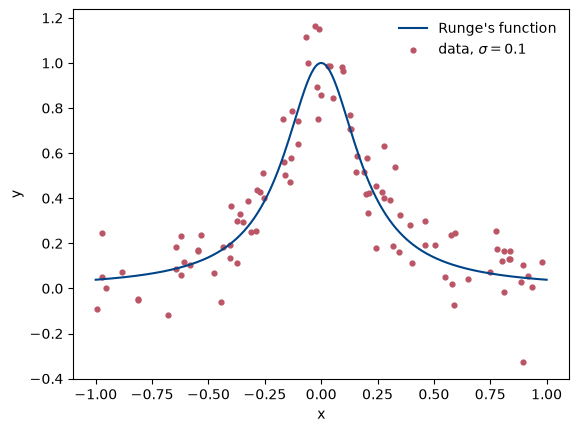

In [28]:
### Generate data and create quicklook
def generate_data(n=100, sigma=0.1, seed=2026):
    rng = np.random.default_rng(seed)     
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    return x, y, n, sigma

x, y, n, sigma = generate_data()

xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

## Part a): Ordinary Least Squares (OLS) for the Runge function
- OLS regression analysis using polynomials up to order 15
- explore dependence on number of data points
- and polynomial degree
- using MSE and R2

Plots:
- theta for increasing polynomial
- metrics as function of polynomial degree

Components:
- train-test split
- scaling/centering of data

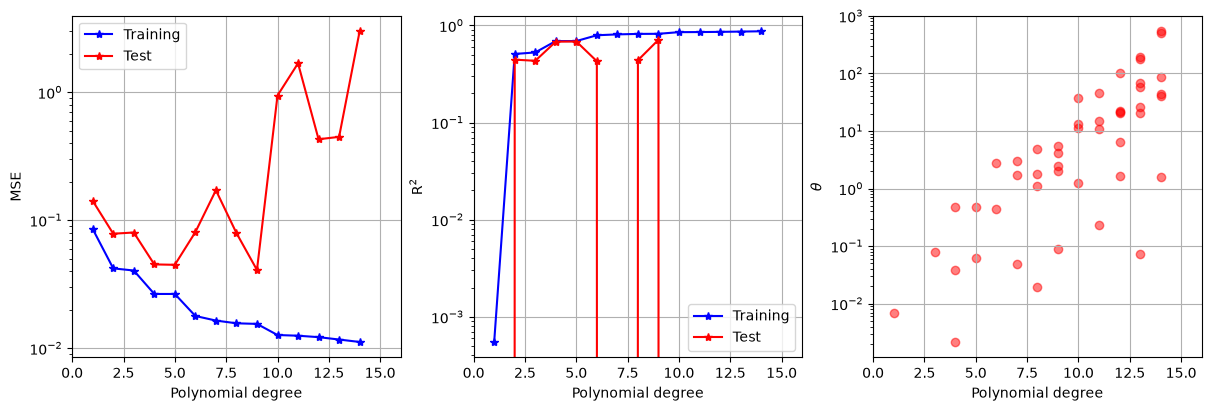

In [29]:
# Splitting data into test and train data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=2026)

### collector function
def prepare_design_matrix(x_train, x_test, y_train, y_test, degree=5, intercept=True):
    """prepares design matrix and scales data"""
    # create design matrix
    X_train = design_matrix(x_train, degree=degree, intercept=intercept)
    X_test = design_matrix(x_test, degree=degree, intercept=intercept)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)
    return X_train_norm, X_test_norm, y_train_norm, y_test_norm

#Adding a model to perform OLS for polynomials up to degree 15
mse_train = []
mse_test = []
r2_train = []
r2_test = []
save_theta = []
for d in range(1,15):
    #Design matrix on the training data:
    X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    #calculate OLS theta
    theta = ols(X_train,y_train)
    save_theta.append(theta)

    #Calculate the MSE:
    mse_train.append(mean_squared_error(y_train, X_train @ theta))
    mse_test.append(mean_squared_error(y_test,  X_test @ theta))
    r2_train.append(r2_score(y_train, X_train @ theta))
    r2_test.append(r2_score(y_test,  X_test @ theta))


#Plotting the MSE as a function of polynomial degree
xx = np.linspace(1,14,14)

fig, ax = plt.subplots(1,3,figsize=(12,4), constrained_layout=True)

for a in ax:
    a.grid()
    a.set_xlim(0,16)
    a.set_yscale('log')

ax[0].plot(xx,mse_train,"b*-",label="Training")
ax[0].plot(xx,mse_test,"r*-",label="Test")
ax[0].set_ylabel("MSE")
ax[0].set_xlabel("Polynomial degree")
ax[0].legend()

ax[1].plot(xx,r2_train,"b*-",label="Training")
ax[1].plot(xx,r2_test,"r*-",label="Test")
ax[1].set_ylabel("R$^2$")
ax[1].set_xlabel("Polynomial degree")
ax[1].legend()

for i in range(len(save_theta)):
    ax[2].scatter(np.full(i+1, xx[i]), save_theta[i], color='r', alpha=0.5)
# ax[2].plot(xx,save_theta,"r*-",label="Test")
ax[2].set_ylabel(r"$\theta$")
ax[2].set_xlabel("Polynomial degree")


plt.show()


## Part b): Adding Ridge regression for the Runge function
- same analysis as a, but with Ridge
- for different values of penalty parameter lambda

Polynomial degree: 1
Minimum MSE is  0.0852454331582845 at lambda = 2.5118864315095823e-07 for training data
Minimum MSE is  0.1408697620662985 at lambda = 10000.0 for test data
Polynomial degree: 2
Minimum MSE is  0.0419864756226363 at lambda = 2.511886431509582e-08 for training data
Minimum MSE is  0.07832073165244044 at lambda = 1e-08 for test data
Polynomial degree: 3
Minimum MSE is  0.0403968803604171 at lambda = 6.30957344480193e-08 for training data
Minimum MSE is  0.0798943307575858 at lambda = 1.5848931924611174 for test data
Polynomial degree: 4
Minimum MSE is  0.026497232884738663 at lambda = 1e-08 for training data
Minimum MSE is  0.04509426766896332 at lambda = 1e-08 for test data
Polynomial degree: 5
Minimum MSE is  0.026493143402373014 at lambda = 1e-08 for training data
Minimum MSE is  0.044767790791748426 at lambda = 1e-08 for test data
Polynomial degree: 6
Minimum MSE is  0.017829076450046364 at lambda = 1e-08 for training data
Minimum MSE is  0.04047207755781056 at l

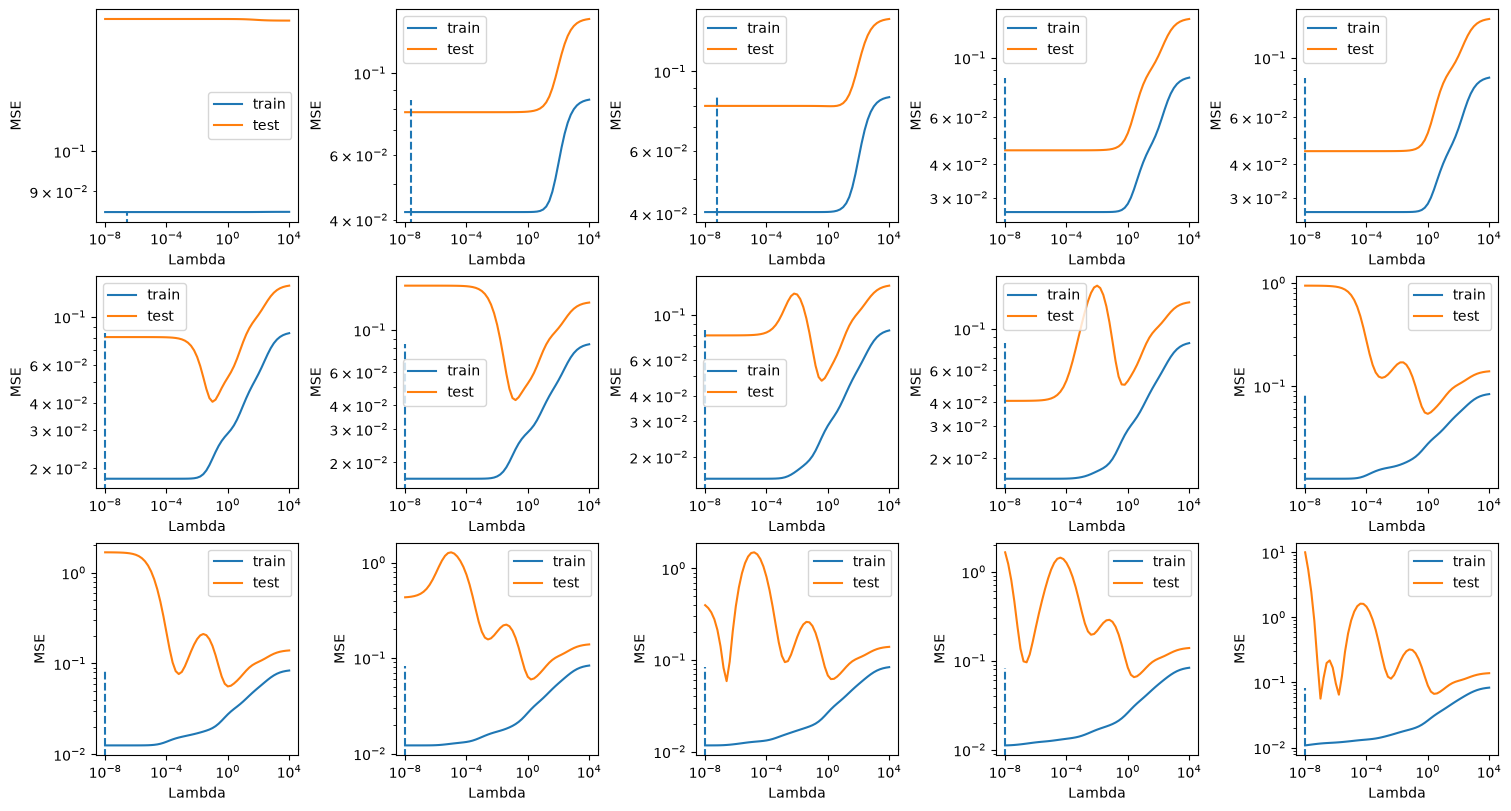

In [30]:
#Adding a model to perform OLS for polynomials up to degree 15
degs = np.arange(1,16)
fig = plt.figure(figsize=(15,8), constrained_layout=True)

for d in degs:
    ax = fig.add_subplot(3,5,d)
    #Design matrix on the training data:
    # X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    X_train = design_matrix(x_train, degree=d, intercept=False)
    X_test = design_matrix(x_test, degree=d, intercept=False)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)

    #Loop through different lambdas and calculate the Ridge regression and MSE
    lambdas = np.logspace(-8, 4, 61)
    mse_train = []
    mse_test = []
    for l in lambdas:
        #Theta from Ridge
        theta = Ridge(alpha=l, fit_intercept=False).fit(X_train_norm, y_train_norm).coef_
        #MSE for train and test data
        mse_train.append(mean_squared_error(y_train_norm, np.mean(y_test) + X_train_norm @ theta))
        mse_test.append(mean_squared_error(y_test_norm,  np.mean(y_test) + X_test_norm @ theta))


    #Plot the results
    ax.plot(lambdas,mse_train,label="train")
    ax.plot(lambdas,mse_test,label="test")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel("MSE")
    ax.set_xlabel("Lambda")
    ax.legend()
    ax.vlines(lambdas[np.argmin(mse_train)],ymin=0,ymax=np.max(mse_train),linestyle="--")

    #Finding the minimum MSE and at what lambda
    print(f"Polynomial degree: {d}")
    print("Minimum MSE is ",np.min(mse_train), "at lambda =", lambdas[np.argmin(mse_train)], "for training data")
    print("Minimum MSE is ",np.min(mse_test), "at lambda =", lambdas[np.argmin(mse_test)], "for test data")

### Part c): The bias-variance tradeoff and the bootstrap

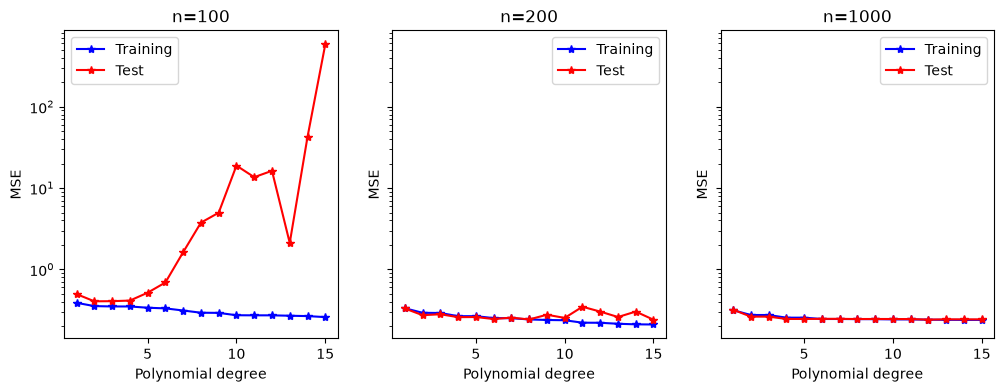

In [31]:
# Your code for part c) heret
### Inspired by figure 2.11 in Hastie et al., 2009

max_deg = 15
fig, ax = plt.subplots(1,3,figsize=(12,4), sharey=True)
for n, i in zip((100, 200, 1000), (0,1,2)):
    # get some new data (but different names to not overwrite the ones used consistently)
    x_c, y_c, n_c, sigma_c = generate_data(n=n, sigma=0.5)
    x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_c, y_c, test_size=0.3,random_state=2026)

    #Adding a model to perform OLS for polynomials up to degree 15
    mse_train = []
    mse_test = []
    for d in range(1,max_deg+1):
        X_train_c, X_test_c, y_train_c, y_test_c = prepare_design_matrix(x_train_c, x_test_c, y_train_c, y_test_c, degree=d, intercept=False)
        
        #calculate OLS theta
        theta = ols(X_train_c,y_train_c)

        #Calculate the MSE:
        mse_train.append(mean_squared_error(y_train_c, X_train_c @ theta))
        mse_test.append(mean_squared_error(y_test_c,  X_test_c @ theta))


    #Plotting the MSE as a function of polynomial degree
    xx = np.linspace(1,max_deg,max_deg)

    ax[i].plot(xx,mse_train,"b*-",label="Training")
    ax[i].plot(xx,mse_test,"r*-",label="Test")
    ax[i].set_ylabel("MSE")
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree")
    ax[i].set_title(f"n={n}")
    ax[i].legend()

plt.show()

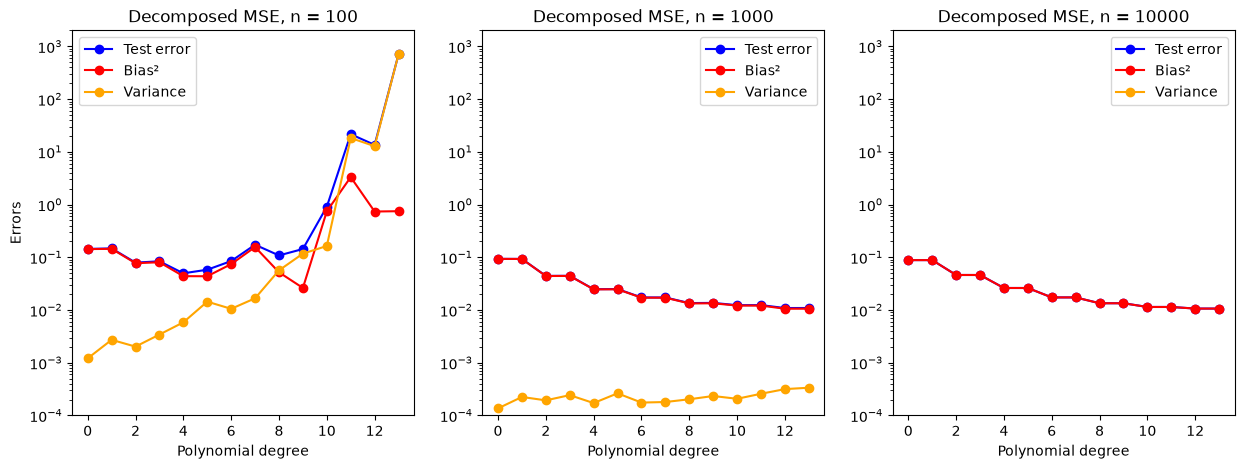

In [32]:
# Your code for exercise 3 here
n_bootstraps = 100 #100 resamples of training data
degree_max = 14 #13 + 1

def bootstrap_polynomial(n, degree_max, sigma=0.1, seed=2026, n_bootstraps=n_bootstraps):
    x, y, _, _ = generate_data(n=n, sigma=sigma, seed=seed)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=seed)

    x_train = x_train.reshape(-1, 1)
    x_test = x_test.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    error = np.zeros(degree_max)
    bias = np.zeros(degree_max)
    variance = np.zeros(degree_max)

    for degree in range(degree_max):
        model = make_pipeline(PolynomialFeatures(degree=degree),
                              LinearRegression(fit_intercept=False))
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

    return error, bias, variance
    

fig, ax = plt.subplots(1,3,figsize=[15,5])
sp = 0 #What subplot / axis to plot

for n in (100, 1000, 10000): #40,100,400
    error, bias, variance = bootstrap_polynomial(n=n, degree_max=degree_max)

    #Plot results
    ax[sp].plot(range(degree_max),error,"o-",color="blue",label="Test error")
    ax[sp].plot(range(degree_max),bias,"o-",color="red", label="Bias²")
    ax[sp].plot(range(degree_max),variance,"o-",color="orange",label="Variance")
    ax[sp].set_title(f"Decomposed MSE, n = {n}")
    ax[sp].set_xlabel("Polynomial degree")
    
    ax[sp].set_ylim(1e-4,2e3)
    ax[sp].set_yscale("log")
    ax[sp].legend()
    sp += 1
ax[0].set_ylabel("Errors")
plt.show()


In [33]:
#Replacing OLS by Ridge regression at fixed degree 12
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance



degree_fixed = 12
lams = [0.0, 1e-4, 1e-1, 10.0]

print(f"degree {degree_fixed}, n = 40, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                       LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg),
                                                StandardScaler(),
                                                Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1,
                                       make_model=mk)
    
    d = degree_fixed
    label = "OLS" if lam == 0.0 else f"{lam:g}"
    print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}")
    

degree 12, n = 40, 100 bootstraps
  lambda       error      bias^2    variance
     OLS      0.0762      0.0284      0.0478
  0.0001      0.0338      0.0272      0.0067
     0.1      0.0289      0.0228      0.0060
      10      0.1020      0.0979      0.0041


## Part d): Cross-validation as a resampling technique

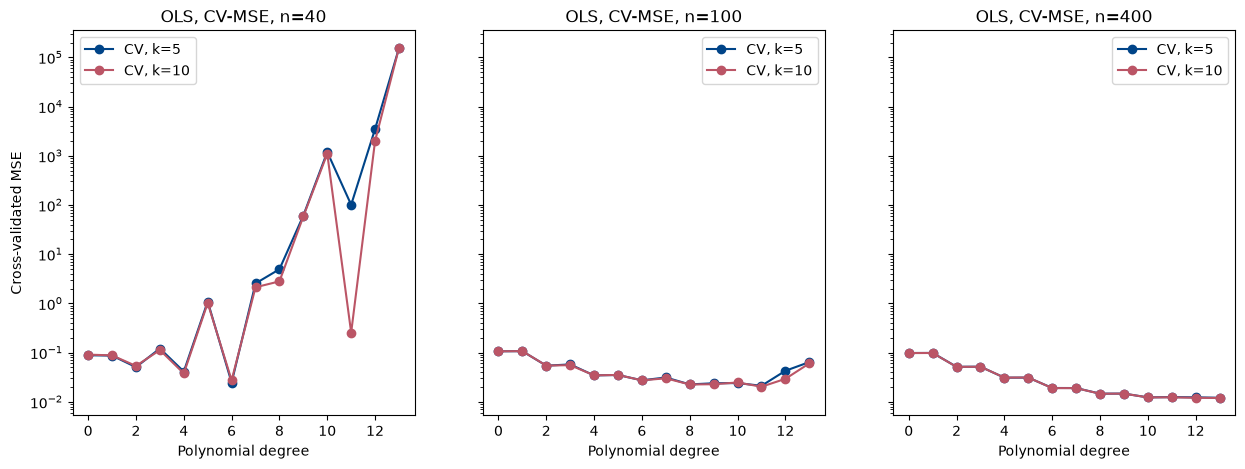

In [34]:
# Use the k-fold cross-validation functionality of Scikit-Learn (KFold together with cross_val_score,
# or cross_validate) and evaluate again the MSE function resulting from the test folds, for the
# OLS analysis of parts a) and c) as a function of the polynomial degree, 

from sklearn.model_selection import KFold, cross_val_score

def cv_mse_ols(x, y, degree_max, k, seed=2026):
    """k-fold CV MSE for OLS, as a function of polynomial degree."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    mse = np.zeros(degree_max)
    for degree in range(degree_max):
        pipe = make_pipeline(PolynomialFeatures(degree=degree),
                              LinearRegression(fit_intercept=False))
        scores = -cross_val_score(pipe, x, y, cv=kf,
                                   scoring="neg_mean_squared_error")
        mse[degree] = scores.mean()
    return mse

# Same n-values as the bootstrap sweep in part c)
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, n in enumerate((40, 100, 400)):
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5  = cv_mse_ols(x_cv, y_cv, degree_max, k=5)
    mse_k10 = cv_mse_ols(x_cv, y_cv, degree_max, k=10)

    ax[i].plot(range(degree_max), mse_k5,  "o-", color="#004488", label="CV, k=5")
    ax[i].plot(range(degree_max), mse_k10, "o-", color="#BB5566", label="CV, k=10")
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree")
    ax[i].set_title(f"OLS, CV-MSE, n={n}")
    ax[i].legend()

ax[0].set_ylabel("Cross-validated MSE")
plt.show()

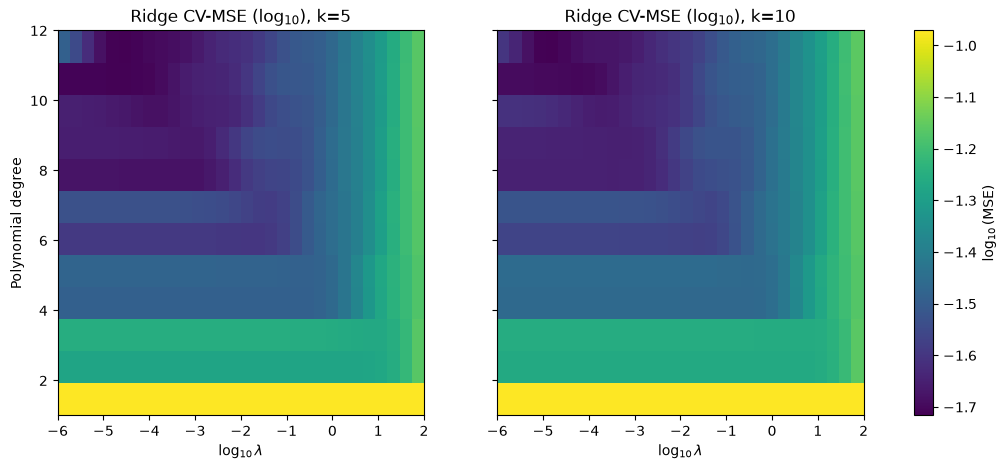

k=5: best degree=12, best lambda=2.395e-05, CV-MSE=0.02073
k=10: best degree=12, best lambda=1.269e-05, CV-MSE=0.01921


In [35]:
# and for Ridge regression
# as a function of both the polynomial degree and λ.

def cv_mse_ridge_grid(x, y, degrees, lambdas, k, seed=2026):
    """k-fold CV MSE for Ridge over a (degree, lambda) grid."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    mse_grid = np.zeros((len(degrees), len(lambdas)))
    for i, degree in enumerate(degrees):
        for j, lmb in enumerate(lambdas):
            pipe = make_pipeline(PolynomialFeatures(degree=degree),
                                  StandardScaler(),
                                  Ridge(alpha=lmb))
            scores = -cross_val_score(pipe, x, y, cv=kf,
                                       scoring="neg_mean_squared_error")
            mse_grid[i, j] = scores.mean()
    return mse_grid

n_ridge = 100
x_r, y_r, _, _ = generate_data(n=n_ridge, sigma=0.1, seed=2026)
x_r = x_r.reshape(-1, 1)

degrees_ridge = list(range(1, 13))
lambdas = np.logspace(-6, 2, 30)

mse_ridge_k5  = cv_mse_ridge_grid(x_r, y_r, degrees_ridge, lambdas, k=5)
mse_ridge_k10 = cv_mse_ridge_grid(x_r, y_r, degrees_ridge, lambdas, k=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, grid, k in zip(axes, (mse_ridge_k5, mse_ridge_k10), (5, 10)):
    im = ax.imshow(np.log10(grid), aspect="auto", origin="lower",
                    extent=[np.log10(lambdas[0]), np.log10(lambdas[-1]),
                            degrees_ridge[0], degrees_ridge[-1]])
    ax.set_xlabel(r"$\log_{10}\lambda$")
    ax.set_title(f"Ridge CV-MSE (log$_{{10}}$), k={k}")
axes[0].set_ylabel("Polynomial degree")
fig.colorbar(im, ax=axes, label=r"$\log_{10}$(MSE)")
plt.show()

for grid, k in zip((mse_ridge_k5, mse_ridge_k10), (5, 10)):
    i_best, j_best = np.unravel_index(np.argmin(grid), grid.shape)
    print(f"k={k}: best degree={degrees_ridge[i_best]}, "
          f"best lambda={lambdas[j_best]:.4g}, CV-MSE={grid[i_best, j_best]:.5f}")

In [36]:
# Optionally, you can
# also write your own k-fold cross-validation code and check that it reproduces the Scikit-Learn
# results when the two use the same fold assignment

def my_kfold_ridge_mse(x, y, degree, lmb, k, seed=2026):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    poly = PolynomialFeatures(degree=degree)
    fold_mse = np.zeros(k)
    for j, (train_idx, test_idx) in enumerate(kf.split(x)):
        x_train, y_train = x[train_idx], y[train_idx]
        x_test,  y_test  = x[test_idx],  y[test_idx]

        X_train = poly.fit_transform(x_train)
        X_test  = poly.transform(x_test)

        scaler = StandardScaler().fit(X_train)
        ridge = Ridge(alpha=lmb).fit(scaler.transform(X_train), y_train)

        y_pred = ridge.predict(scaler.transform(X_test))
        fold_mse[j] = np.mean((y_pred - y_test) ** 2)
    return fold_mse.mean()

# Sanity check against cross_val_score, at one (degree, lambda) point
degree_check, lmb_check, k_check = 6, 1.0, 5
mine = my_kfold_ridge_mse(x_r, y_r, degree_check, lmb_check, k_check)

kf = KFold(n_splits=k_check, shuffle=True, random_state=2026)
pipe = make_pipeline(PolynomialFeatures(degree=degree_check), StandardScaler(), Ridge(alpha=lmb_check))
sklearn_mse = -cross_val_score(pipe, x_r, y_r, cv=kf, scoring="neg_mean_squared_error").mean()

print(f"own loop: {mine:.6f}   sklearn: {sklearn_mse:.6f}")

own loop: 0.036699   sklearn: 0.036699


n=40: best degree — CV(k=5)=6, CV(k=10)=6, bootstrap=6
n=100: best degree — CV(k=5)=11, CV(k=10)=11, bootstrap=4
n=400: best degree — CV(k=5)=13, CV(k=10)=13, bootstrap=13


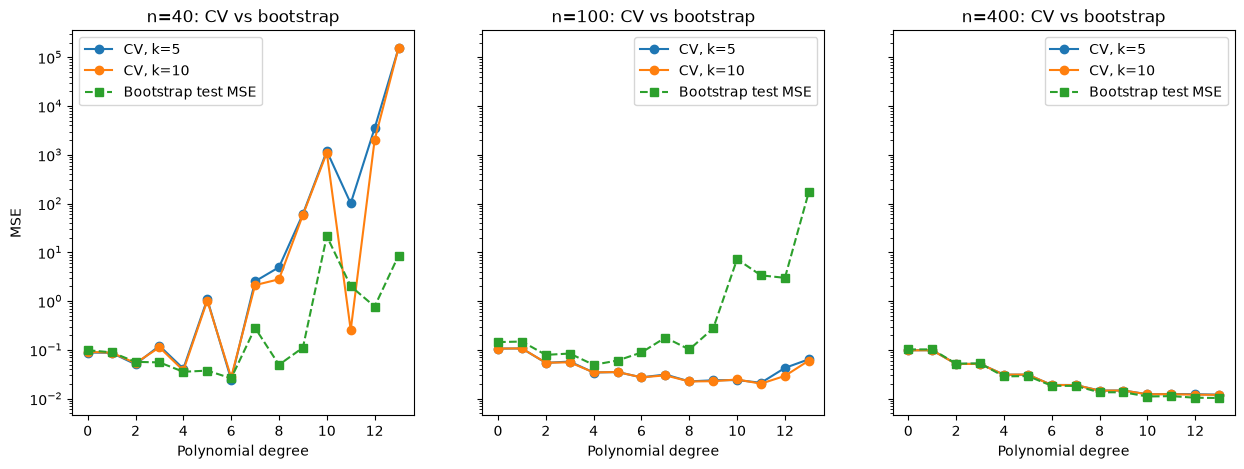

In [37]:
# Compare the MSE you get from cross-validation with the one you got from your bootstrap
# code in part c).

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, n in enumerate((40, 100, 400)):
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5  = cv_mse_ols(x_cv, y_cv, degree_max, k=5)
    mse_k10 = cv_mse_ols(x_cv, y_cv, degree_max, k=10)
    error_boot, _, _ = bootstrap_polynomial(n=n, degree_max=degree_max)

    ax[i].plot(range(degree_max), mse_k5, "o-", label="CV, k=5")
    ax[i].plot(range(degree_max), mse_k10, "o-", label="CV, k=10")
    ax[i].plot(range(degree_max), error_boot, "s--", label="Bootstrap test MSE")
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree")
    ax[i].set_title(f"n={n}: CV vs bootstrap")
    ax[i].legend()

    print(f"n={n}: best degree — CV(k=5)={np.argmin(mse_k5)}, "
          f"CV(k=10)={np.argmin(mse_k10)}, bootstrap={np.argmin(error_boot)}")

ax[0].set_ylabel("MSE")
plt.show()